# Laboratorio 5: Análisis de sentimiento y variable de negatividad

Se utiliza `train_clean.csv` (notebook 01) y el vectorizador TF-IDF guardado en el notebook 04.

**Este notebook cubre:**
- Punto 8: Clasificación de palabras en positivas, negativas y neutras, y puntuación de sentimiento de cada tweet.
- Punto 9: Tweets más negativos y más positivos, y comparación de sentimiento entre categorías.
- Punto 10: Variable de negatividad y reentrenamiento del modelo de clasificación con esa variable.

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import html
import joblib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from scipy.stats import mannwhitneyu
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

pd.set_option("display.max_colwidth", 110)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Carga del dataset preprocesado

In [2]:
df = pd.read_csv("./data/train_clean.csv")
df["clean_text"] = df["clean_text"].fillna("")

print(f"Total de tweets: {len(df):,}")
df[["text", "clean_text", "target"]].head(3)

Total de tweets: 7,613


,text,clean_text,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake may allah forgive us,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter i...,residents asked shelter place notified officers evacuation shelter place orders expected,1


## 2. Léxico de sentimiento (Punto 8)

Para determinar si una palabra es positiva, negativa o neutra se usa el léxico **VADER**
(*Valence Aware Dictionary and sEntiment Reasoner*), incluido en `nltk.sentiment.vader`. Se eligió sobre
`TextBlob` porque fue construido específicamente para redes sociales: además de asignar una valencia a cada
palabra, entiende emoticones, mayúsculas sostenidas, signos de exclamación, intensificadores (`very`) y
negaciones (`not good`), que son frecuentes en tweets.

Referencia: Hutto, C.J. y Gilbert, E.E. (2014). *VADER: A Parsimonious Rule-based Model for Sentiment Analysis of
Social Media Text*. Eighth International Conference on Weblogs and Social Media (ICWSM-14).

Cada entrada del léxico tiene una valencia entre -4 (muy negativa) y +4 (muy positiva).

In [3]:
sia = SentimentIntensityAnalyzer()
lexico = sia.lexicon

print(f"Palabras en el léxico VADER: {len(lexico):,}")
ejemplos_lexico = ["disaster", "fire", "emergency", "love", "good", "table", "rescue", "killed"]
pd.DataFrame({
    "palabra": ejemplos_lexico,
    "valencia": [lexico.get(p, 0.0) for p in ejemplos_lexico],
})

Palabras en el léxico VADER: 7,502


,palabra,valencia
0,disaster,-3.1
1,fire,-1.4
2,emergency,-1.6
3,love,3.2
4,good,1.9
5,table,0.0
6,rescue,2.3
7,killed,-3.5


### 2.1 Clasificación de las palabras del corpus

Se recorre el vocabulario del texto limpio y se etiqueta cada palabra como positiva, negativa o neutra. Se usa un
umbral de 0.5 en valor absoluto para evitar que palabras con valencia muy débil cuenten como polarizadas.

In [4]:
UMBRAL_VALENCIA = 0.5


def clasificar_palabra(palabra):
    valencia = lexico.get(palabra)
    if valencia is None or abs(valencia) < UMBRAL_VALENCIA:
        return "neutra"
    return "positiva" if valencia > 0 else "negativa"


vocabulario = Counter(w for t in df["clean_text"] for w in t.split())
polaridad_vocabulario = pd.Series({w: clasificar_palabra(w) for w in vocabulario})

total_tokens = sum(vocabulario.values())
tokens_polarizados = sum(c for w, c in vocabulario.items() if clasificar_palabra(w) != "neutra")

print(f"Palabras únicas en el corpus limpio: {len(vocabulario):,}")
print(polaridad_vocabulario.value_counts().to_string())
print(f"\nCobertura: {tokens_polarizados / total_tokens * 100:.1f}% de los tokens del corpus "
      f"tienen polaridad asignada.")

Palabras únicas en el corpus limpio: 14,279
neutra      12914
negativa      771
positiva      594

Cobertura: 16.4% de los tokens del corpus tienen polaridad asignada.


### 2.2 Palabras polarizadas más frecuentes en cada categoría

In [5]:
def top_polaridad(target, polaridad, n=10):
    conteo = Counter(
        w for t in df.loc[df["target"] == target, "clean_text"].str.split() for w in t
        if clasificar_palabra(w) == polaridad
    )
    return [f"{palabra} ({veces})" for palabra, veces in conteo.most_common(n)]


tabla_polaridad = pd.DataFrame({
    "negativas (desastre real)": top_polaridad(1, "negativa"),
    "positivas (desastre real)": top_polaridad(1, "positiva"),
    "negativas (no desastre)": top_polaridad(0, "negativa"),
    "positivas (no desastre)": top_polaridad(0, "positiva"),
}, index=range(1, 11))
tabla_polaridad

,negativas (desastre real),positivas (desastre real),negativas (no desastre),positivas (no desastre)
1,fire (182),like (94),emergency (81),like (254)
2,disaster (121),please (27),fire (72),love (91)
3,suicide (112),natural (27),wreck (46),good (67)
4,killed (95),help (25),fear (44),lol (62)
5,crash (85),rescue (22),ass (42),best (55)
6,emergency (77),security (21),death (39),help (49)
7,bomb (75),hope (21),bloody (38),great (47)
8,attack (71),rescued (21),shit (37),god (46)
9,accident (68),good (20),screaming (37),please (46)
10,dead (63),ok (20),ruin (37),top (41)


Las palabras negativas de la clase desastre real son sustantivos factuales de emergencias (`fire`,
`disaster`, `suicide`, `killed`, `crash`, `bomb`), mientras que en la clase no desastre las negativas son
mayormente expresiones coloquiales o groserías (`ass`, `bloody`, `shit`) junto con usos figurados de `wreck` y
`fire`. Del lado positivo, en desastre real aparecen palabras del vocabulario de respuesta a emergencias (`help`,
`rescue`, `hope`, `security`), lo cual muestra un detalle importante: una palabra puede ser positiva en el léxico
y aun así ser señal fuerte de desastre. La polaridad y la clase objetivo miden cosas distintas, aunque estén
correlacionadas.

## 3. ¿Vale la pena conservar los emoticones? (Punto 8)

El preprocesamiento del notebook 01 elimina la puntuación, y con ella cualquier emoticón ASCII (`:)`, `:(`, `;)`).
En el notebook 01 ya se verificó que el dataset no contiene emojis Unicode, pero los emoticones de texto son otra
historia. Se revisa cuántos hay y qué tan informativos son.

In [6]:
emoticones_lexico = {t for t in lexico if not re.search(r"[a-zA-Z0-9]", t)}
print(f"Emoticones reconocidos por VADER: {len(emoticones_lexico)}")

sin_url = df["text"].str.replace(r"https?://\S+|www\.\S+", " ", regex=True)
tiene_emoticon = sin_url.apply(lambda t: any(tok in emoticones_lexico for tok in t.split()))

print(f"Tweets con al menos un emoticón: {tiene_emoticon.sum()} "
      f"({tiene_emoticon.mean() * 100:.2f}% del total)")
print(f"Proporción de desastre real entre tweets con emoticón : {df.loc[tiene_emoticon, 'target'].mean():.3f}")
print(f"Proporción de desastre real entre tweets sin emoticón : {df.loc[~tiene_emoticon, 'target'].mean():.3f}")

conteo_emoticones = Counter(tok for t in sin_url for tok in t.split() if tok in emoticones_lexico)
print("\nEmoticones más usados:", conteo_emoticones.most_common(8))

Emoticones reconocidos por VADER: 151
Tweets con al menos un emoticón: 47 (0.62% del total)
Proporción de desastre real entre tweets con emoticón : 0.106
Proporción de desastre real entre tweets sin emoticón : 0.432

Emoticones más usados: [(':)', 16), (':(', 8), (';)', 6), (':-)', 6), (':/', 3), ('=/', 2), ('):', 2), ('/:', 1)]


In [7]:
# Efecto concreto de conservar o eliminar el emoticón
ejemplo_emoticon = df.loc[tiene_emoticon, "text"].iloc[2]
sin_emoticon = " ".join(t for t in ejemplo_emoticon.split() if t not in emoticones_lexico)

print("Con emoticón :", ejemplo_emoticon)
print("  ->", sia.polarity_scores(ejemplo_emoticon))
print("\nSin emoticón :", sin_emoticon)
print("  ->", sia.polarity_scores(sin_emoticon))

Con emoticón : @ACarewornHeart Have a good un fella sorry I won't be there to get annihilated with you :(
  -> {'neg': 0.22, 'neu': 0.628, 'pos': 0.152, 'compound': -0.0772}

Sin emoticón : @ACarewornHeart Have a good un fella sorry I won't be there to get annihilated with you
  -> {'neg': 0.08, 'neu': 0.741, 'pos': 0.179, 'compound': 0.3818}


Los emoticones aparecen en menos del 1% de los tweets, así que su impacto agregado es pequeño, pero
son muy informativos donde aparecen: entre los tweets con emoticón solo el 10.6% habla de un desastre real, frente
al 43.2% del resto del corpus. Tiene sentido, ya que nadie acompaña una noticia de catástrofe con una carita
feliz. El ejemplo anterior muestra además que el emoticón cambia el signo del resultado: con `:(` el tweet
puntúa -0.077 y sin él pasa a +0.382, porque sin la carita solo quedan `good` y `sorry` compitiendo entre sí.

**Decisión:** para el análisis de sentimiento se usa una limpieza más ligera que la del notebook 01, conservando
puntuación, mayúsculas y emoticones, y quitando únicamente URLs, menciones, el símbolo de los hashtags y los
artefactos de codificación. Para el modelo de clasificación se mantiene el texto limpio original, ya que ahí el
aporte de los emoticones es marginal frente al vocabulario.

In [8]:
def corregir_mojibake(texto):
    texto = re.sub(r"\x89Û_", "'", texto)
    texto = re.sub(r"\x89Û[ÒÓªÏ]", " ", texto)
    texto = re.sub(r"åÊ|åÈ", " ", texto)
    texto = re.sub(r"[\x80-\x9f]", " ", texto)
    return texto


def preparar_para_sentimiento(texto):
    """Limpieza ligera: conserva puntuación, mayúsculas y emoticones, que VADER sí aprovecha."""
    texto = corregir_mojibake(texto)
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = html.unescape(texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"#(\w+)", r"\1", texto)
    return re.sub(r"\s+", " ", texto).strip()


df["texto_sentimiento"] = df["text"].apply(preparar_para_sentimiento)
df[["text", "texto_sentimiento"]].sample(4, random_state=RANDOM_STATE)

,text,texto_sentimiento
2644,So you have a new weapon that can cause un-imaginable destruction.,So you have a new weapon that can cause un-imaginable destruction.
2227,The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mis...,The f$& things I do for GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @/@
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... htt...,DT : RT : The CoL police can catch a pickpocket in Liverpool Stree...
132,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a grea...,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a grea...


## 4. Puntuación de sentimiento de cada tweet (Punto 8)

Se calculan dos medidas para poder compararlas:

1. **Conteo de palabras polarizadas**, que es lo que pide el enunciado: se cuentan las palabras positivas y
   negativas del tweet y se resume en un índice `(n_pos - n_neg) / (n_pos + n_neg)`, que va de -1 a 1. El tweet es
   positivo si predominan las positivas, negativo si predominan las negativas y neutro si hay empate o si no tiene
   palabras polarizadas.
2. **Puntuación compuesta de VADER** (`compound`), calculada sobre el texto con limpieza ligera. También va de -1
   a 1, pero además pondera la intensidad de cada palabra y aplica reglas de negación, intensificadores,
   mayúsculas y signos de exclamación.

In [9]:
def contar_polaridad(texto_limpio):
    n_pos = n_neg = 0
    palabras = texto_limpio.split()
    for palabra in palabras:
        categoria = clasificar_palabra(palabra)
        if categoria == "positiva":
            n_pos += 1
        elif categoria == "negativa":
            n_neg += 1
    return n_pos, n_neg, len(palabras) - n_pos - n_neg


conteos = df["clean_text"].apply(contar_polaridad)
df[["n_pos", "n_neg", "n_neutras"]] = pd.DataFrame(conteos.tolist(), index=df.index)

df["score_conteo"] = np.where(
    (df["n_pos"] + df["n_neg"]) > 0,
    (df["n_pos"] - df["n_neg"]) / (df["n_pos"] + df["n_neg"]),
    0.0
)


def categoria_por_conteo(fila):
    if fila["n_pos"] > fila["n_neg"]:
        return "positivo"
    if fila["n_neg"] > fila["n_pos"]:
        return "negativo"
    return "neutro"


df["cat_conteo"] = df.apply(categoria_por_conteo, axis=1)
df[["clean_text", "n_pos", "n_neg", "score_conteo", "cat_conteo"]].head(5)

,clean_text,n_pos,n_neg,score_conteo,cat_conteo
0,deeds reason earthquake may allah forgive us,1,0,1.0,positivo
1,forest fire near la ronge sask canada,0,1,-1.0,negativo
2,residents asked shelter place notified officers evacuation shelter place orders expected,0,0,0.0,neutro
3,people receive wildfires evacuation orders california,0,0,0.0,neutro
4,got sent photo ruby alaska smoke wildfires pours school,0,0,0.0,neutro


In [10]:
df["compound"] = df["texto_sentimiento"].apply(lambda t: sia.polarity_scores(t)["compound"])


def categoria_por_vader(compound):
    if compound >= 0.05:
        return "positivo"
    if compound <= -0.05:
        return "negativo"
    return "neutro"


df["cat_vader"] = df["compound"].apply(categoria_por_vader)

distribucion = pd.DataFrame({
    "conteo de palabras": df["cat_conteo"].value_counts(normalize=True),
    "VADER (compound)": df["cat_vader"].value_counts(normalize=True),
}).round(3)
print("Distribución de categorías de sentimiento:")
print(distribucion.to_string())
print(f"\nCoincidencia entre ambos métodos: {(df['cat_conteo'] == df['cat_vader']).mean() * 100:.1f}%")

Distribución de categorías de sentimiento:
          conteo de palabras  VADER (compound)
negativo               0.435             0.492
neutro                 0.357             0.254
positivo               0.208             0.253

Coincidencia entre ambos métodos: 84.1%


In [11]:
# Casos donde los dos métodos no coinciden
discrepancias = df[df["cat_conteo"] != df["cat_vader"]]
discrepancias[["text", "cat_conteo", "cat_vader", "compound"]].sample(6, random_state=RANDOM_STATE)

,text,cat_conteo,cat_vader,compound
621,@DrRichardBesser Yes. I would think not. But since college 88-92 it's been difficult not to think of biote...,neutro,negativo,-0.3400
4798,I WAS PEACEFULLY SITTING IN MY ROOM AND I HEARD THIS LOUD BANG OF SOMETHING FALLING,neutro,positivo,0.4215
5452,@robbiewilliams U fkn asswipe playing for Israeli child killers.. The fkn karma police will get U.,neutro,positivo,0.2023
700,@bekah__w thanks! I sweat bullets every time I get in with this blazing sun beating down on me.,neutro,negativo,-0.1007
3837,'NO LENDER FEES FOR VETERANS OR FIRST RESPONDERS (PAST AND PRESENT)' on @LinkedIn https://t.co/9pmBTxmoAL,neutro,negativo,-0.4466
2747,In this fragile global economy considering the devastation the alternatives would cause ... it's the best ...,neutro,positivo,0.3400


Los dos métodos coinciden en el 84.1% de los tweets, y las diferencias son sistemáticas. El conteo
simple clasifica como neutro cualquier tweet sin palabras del léxico (un 35.7% del corpus frente al 25.4% de
VADER), mientras que VADER, al trabajar sobre el texto sin quitar *stopwords* ni puntuación, encuentra señal en
negaciones, intensificadores, mayúsculas sostenidas y signos de exclamación que el conteo pierde. En la muestra de
discrepancias se ve el patrón: todos son tweets que el conteo dejó en neutro y que VADER sí logra inclinar hacia
un lado. También ocurre el caso inverso, cuando un tweet con una palabra positiva y una negativa queda neutro por
empate en el conteo pero VADER lo resuelve según la intensidad de cada una. Por eso se usa `compound` como medida
principal en los puntos 9 y 10, dejando el conteo como la versión pedida explícitamente en el enunciado.

## 5. Sentimiento por categoría de tweet (Punto 9)

### 5.1 Los 10 tweets más negativos

In [12]:
ETIQUETAS = {0: "No desastre", 1: "Desastre real"}
df["categoria"] = df["target"].map(ETIQUETAS)

top_negativos = df.nsmallest(10, "compound")[["text", "categoria", "compound", "n_pos", "n_neg"]]
top_negativos

,text,categoria,compound,n_pos,n_neg
7472,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?,No desastre,-0.9883,0,13
6414,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at ...,Desastre real,-0.9686,0,5
6411,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an a...,Desastre real,-0.9623,1,5
6393,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. T...,Desastre real,-0.9595,0,5
6407,17 killed in SÛªArabia mosque suicide bombing\n\nA suicide bomber attacked a mosque in Aseer south-wester...,Desastre real,-0.9552,0,4
2932,at the lake \n*sees a dead fish*\nme: poor little guy i wonder what happened\nashley: idk maybe it drowned...,No desastre,-0.9549,0,4
472,illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Santa Maria CA Woman Had Pri...,Desastre real,-0.9538,0,5
1540,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violence Drugs Cartel Cocai...,Desastre real,-0.9524,1,7
6818,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on...,Desastre real,-0.9500,0,4
6930,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the world. You create terro...,Desastre real,-0.9493,1,4


In [13]:
print("Distribución por categoría de los 10 tweets más negativos:")
print(top_negativos["categoria"].value_counts().to_string())

Distribución por categoría de los 10 tweets más negativos:
categoria
Desastre real    8
No desastre      2


### 5.2 Los 10 tweets más positivos

In [14]:
top_positivos = df.nlargest(10, "compound")[["text", "categoria", "compound", "n_pos", "n_neg"]]
top_positivos

,text,categoria,compound,n_pos,n_neg
6992,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at http://t.co/3GEROQ49o...,No desastre,0.9730,5,0
6534,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Ho...,No desastre,0.9564,5,1
6292,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let y...,Desastre real,0.9471,5,0
3163,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great...,No desastre,0.9423,5,1
3382,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great...,No desastre,0.9423,5,1
6295,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please ...,No desastre,0.9376,5,0
2457,@Raishimi33 :) well I think that sounds like a fine plan where little derailment is possible so I applaud ...,Desastre real,0.9356,4,0
1001,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.,No desastre,0.9345,4,0
6560,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2 movies. Let's hope ...,No desastre,0.9344,5,0
6140,Super sweet and beautiful :) https://t.co/TUi9uwBvVp,No desastre,0.9300,3,0


In [15]:
print("Distribución por categoría de los 10 tweets más positivos:")
print(top_positivos["categoria"].value_counts().to_string())

Distribución por categoría de los 10 tweets más positivos:
categoria
No desastre      8
Desastre real    2


De los 10 tweets más negativos, 8 son de la categoría desastre real y corresponden a
noticias de atentados suicidas, bombardeos y asesinatos, es decir, tweets que acumulan varias palabras de alta
carga negativa en una sola oración. Los 2 casos de no desastre en ese extremo son un tweet que repite trece veces
la palabra `wreck` y una anécdota sobre un pez muerto, ninguno de los dos un desastre real.

En el extremo opuesto, 8 de los 10 tweets más positivos son de la categoría no desastre: promociones, mensajes de
agradecimiento y conversaciones personales. Los 2 de desastre real que aparecen ahí son interesantes, ya que usan
palabras de catástrofe en sentido figurado (una frase motivacional sobre "la tormenta que pasará" y un comentario
casual que menciona `derailment`), pero fueron etiquetados como desastre en el dataset. Esto confirma que el
sentimiento y la clase objetivo no son lo mismo, y de paso muestra que hay algo de ruido en las etiquetas
originales.

### 5.3 ¿Son más negativos los tweets de desastre real? (Punto 9.3)

In [16]:
resumen_sentimiento = df.groupby("categoria")["compound"].agg(
    ["mean", "median", "std", "min", "max"]
).round(3)
print(resumen_sentimiento.to_string())

print("\nDistribución de categorías de sentimiento dentro de cada clase (proporciones por columna):")
print(pd.crosstab(df["cat_vader"], df["categoria"], normalize="columns").round(3).to_string())

                mean  median    std    min    max
categoria                                        
Desastre real -0.269  -0.318  0.435 -0.969  0.947
No desastre   -0.056   0.000  0.462 -0.988  0.973

Distribución de categorías de sentimiento dentro de cada clase (proporciones por columna):
categoria  Desastre real  No desastre
cat_vader                            
negativo           0.577        0.428
neutro             0.260        0.250
positivo           0.163        0.322


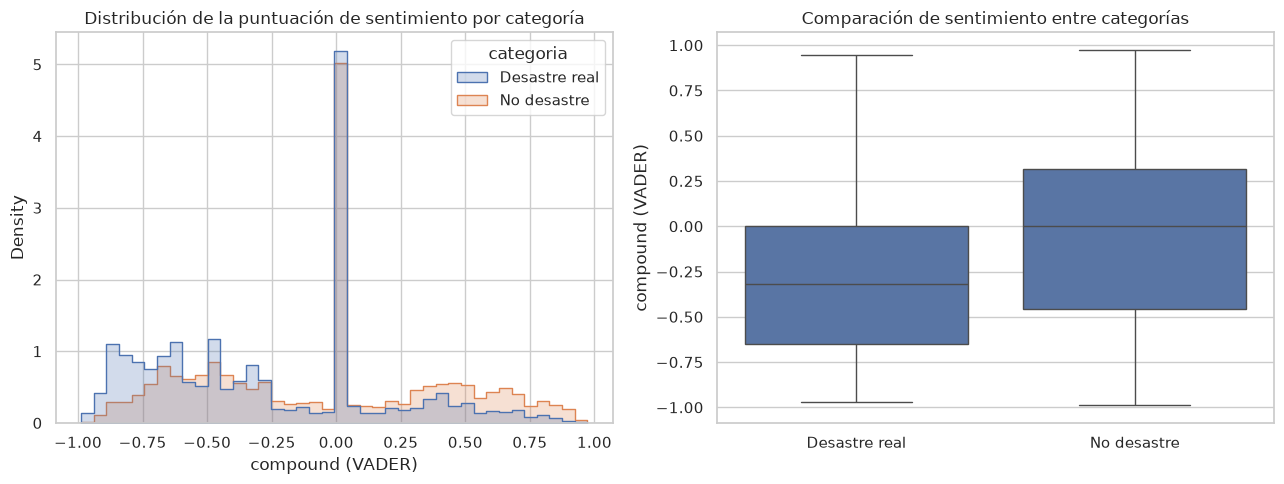

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x="compound", hue="categoria", bins=40, element="step",
             stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Distribución de la puntuación de sentimiento por categoría")
axes[0].set_xlabel("compound (VADER)")

sns.boxplot(data=df, x="categoria", y="compound", ax=axes[1])
axes[1].set_title("Comparación de sentimiento entre categorías")
axes[1].set_xlabel("")
axes[1].set_ylabel("compound (VADER)")

plt.tight_layout()
plt.show()

In [18]:
compound_desastre = df.loc[df["target"] == 1, "compound"]
compound_no_desastre = df.loc[df["target"] == 0, "compound"]

estadistico, p_valor = mannwhitneyu(compound_desastre, compound_no_desastre, alternative="less")
print("Prueba de Mann-Whitney (hipótesis: los tweets de desastre real son más negativos)")
print(f"  U = {estadistico:,.0f}")
print(f"  p-valor = {p_valor:.3e}")

Prueba de Mann-Whitney (hipótesis: los tweets de desastre real son más negativos)
  U = 5,271,106
  p-valor = 2.371e-84


Sí, los tweets de desastre real son claramente más negativos. Su puntuación media de
sentimiento es de -0.269 frente a -0.056 en los tweets de no desastre, y la mediana pasa de 0.000 a -0.318, es
decir, el tweet típico de desastre tiene carga negativa mientras que el de la otra clase es neutro. Visto por
categorías de sentimiento, el 57.7% de los tweets de desastre real son negativos contra el 42.8% de los de no
desastre, y la proporción de positivos cae del 32.2% al 16.3%. El histograma muestra el mismo patrón: la clase de
desastre acumula masa en la zona negativa, mientras que la de no desastre es más simétrica y con un pico marcado
en cero. La prueba de Mann-Whitney confirma que la diferencia no es producto del azar (p del orden de 1e-84).

Aun así, el traslape entre ambas distribuciones es grande, ya que casi el 43% de los tweets de no desastre también
son negativos, porque Twitter está lleno de quejas, insultos y noticias desagradables que no son desastres. Esa es
la razón por la que el sentimiento, por sí solo, no basta para clasificar.

## 6. Variable de negatividad (Punto 10)

Se define `negatividad = (1 - compound) / 2`, una transformación lineal de la puntuación de VADER que la lleva al
rango de 0 a 1, donde 0 es un tweet muy positivo y 1 un tweet muy negativo. Se guarda el dataset con esta variable
y con las columnas de sentimiento para poder reutilizarlas en el informe.

In [19]:
df["negatividad"] = (1 - df["compound"]) / 2

print(df.groupby("categoria")["negatividad"].describe().round(3).to_string())

columnas_salida = ["id", "keyword", "text", "clean_text", "texto_sentimiento",
                   "n_pos", "n_neg", "n_neutras", "score_conteo", "cat_conteo",
                   "compound", "cat_vader", "negatividad", "target"]
df[columnas_salida].to_csv("./data/train_sentiment.csv", index=False)
print("\nArchivo './data/train_sentiment.csv' guardado con", len(df), "filas.")

                count   mean    std    min    25%    50%    75%    max
categoria                                                             
Desastre real  3271.0  0.634  0.217  0.026  0.500  0.659  0.824  0.984
No desastre    4342.0  0.528  0.231  0.014  0.341  0.500  0.729  0.994

Archivo './data/train_sentiment.csv' guardado con 7613 filas.


## 7. Reentrenamiento del modelo con la variable de negatividad (Punto 10)

Se repite exactamente el montaje del notebook 04: misma división 80/20 estratificada con la misma semilla, el
mismo vectorizador TF-IDF guardado y una Regresión Logística con los hiperparámetros ganadores (`C = 1`). La única
diferencia es que a la matriz TF-IDF se le concatena una columna adicional con la negatividad del tweet. De esta
forma, cualquier cambio en las métricas se debe únicamente a la variable nueva.

In [20]:
vectorizador = joblib.load("./models/tfidf_vectorizer.pkl")

X_train, X_test, y_train, y_test, neg_train, neg_test = train_test_split(
    df["clean_text"], df["target"], df["negatividad"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["target"]
)

X_train_tfidf = vectorizador.transform(X_train)
X_test_tfidf = vectorizador.transform(X_test)

X_train_neg = hstack([X_train_tfidf, csr_matrix(neg_train.values.reshape(-1, 1))]).tocsr()
X_test_neg = hstack([X_test_tfidf, csr_matrix(neg_test.values.reshape(-1, 1))]).tocsr()

print("Sin negatividad:", X_train_tfidf.shape)
print("Con negatividad:", X_train_neg.shape)

Sin negatividad: (6090, 9232)
Con negatividad: (6090, 9233)


In [21]:
def evaluar(nombre, X_tr, X_te):
    modelo = LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE)
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    f1_cv = cross_val_score(modelo, X_tr, y_train, cv=5, scoring="f1").mean()
    return modelo, {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "f1_cv_train": f1_cv,
    }


modelo_base, fila_base = evaluar("TF-IDF (notebook 04)", X_train_tfidf, X_test_tfidf)
modelo_neg, fila_neg = evaluar("TF-IDF + negatividad", X_train_neg, X_test_neg)

comparacion = pd.DataFrame([fila_base, fila_neg]).set_index("modelo").round(4)
comparacion

,accuracy,precision,recall,f1,f1_cv_train
modelo,,,,,
TF-IDF (notebook 04),0.8253,0.8502,0.7202,0.7798,0.7305
TF-IDF + negatividad,0.8221,0.8450,0.7171,0.7758,0.7176


In [22]:
diferencia = (comparacion.loc["TF-IDF + negatividad"] - comparacion.loc["TF-IDF (notebook 04)"]).round(4)
print("Diferencia (con negatividad menos base):")
print(diferencia.to_string())

print(f"\nCoeficiente asignado a la variable de negatividad: {modelo_neg.coef_[0][-1]:.4f}")

Diferencia (con negatividad menos base):
accuracy      -0.0032
precision     -0.0052
recall        -0.0031
f1            -0.0040
f1_cv_train   -0.0129

Coeficiente asignado a la variable de negatividad: 1.6688


### 7.1 Variantes probadas

In [23]:
# Negatividad estandarizada, por si la escala de la variable densa fuera el problema
media, desviacion = neg_train.mean(), neg_train.std()
X_train_std = hstack([X_train_tfidf,
                      csr_matrix(((neg_train - media) / desviacion).values.reshape(-1, 1))]).tocsr()
X_test_std = hstack([X_test_tfidf,
                     csr_matrix(((neg_test - media) / desviacion).values.reshape(-1, 1))]).tocsr()

# Solo negatividad, para medir cuánta señal tiene la variable por sí sola
X_train_solo = csr_matrix(neg_train.values.reshape(-1, 1))
X_test_solo = csr_matrix(neg_test.values.reshape(-1, 1))

_, fila_std = evaluar("TF-IDF + negatividad estandarizada", X_train_std, X_test_std)
_, fila_solo = evaluar("Solo negatividad", X_train_solo, X_test_solo)

pd.DataFrame([fila_base, fila_neg, fila_std, fila_solo]).set_index("modelo").round(4)

,accuracy,precision,recall,f1,f1_cv_train
modelo,,,,,
TF-IDF (notebook 04),0.8253,0.8502,0.7202,0.7798,0.7305
TF-IDF + negatividad,0.8221,0.8450,0.7171,0.7758,0.7176
TF-IDF + negatividad estandarizada,0.8194,0.8378,0.7187,0.7737,0.7171
Solo negatividad,0.6041,0.5503,0.4266,0.4806,0.4748


La inclusión de la variable de negatividad **no mejoró** el modelo. El F1 baja de 0.7798
a 0.7758 y el accuracy de 0.8253 a 0.8221, una caída pequeña pero consistente que también se observa en la
validación cruzada sobre el conjunto de entrenamiento (F1 de 0.7305 a 0.7176), así que no es ruido de una sola
partición. Estandarizar la variable tampoco ayuda (F1 de 0.7737), con lo que se descarta que el problema sea la
escala.

La explicación está en la redundancia. La negatividad se calcula a partir de las mismas palabras que ya están en
la matriz TF-IDF: cuando un tweet contiene `killed`, `bomb` o `disaster`, el modelo lineal ya tiene esos términos
como *features* con sus propios coeficientes, y la negatividad no aporta información nueva sino una versión
comprimida y con pérdida de la misma señal. El modelo entrenado únicamente con la negatividad lo confirma: llega a
un F1 de 0.4806, muy por debajo del 0.7798 del TF-IDF. La variable sí tiene señal, y su coeficiente positivo de
1.67 indica que a mayor negatividad mayor probabilidad de desastre, coherente con lo encontrado en el punto 9.3,
pero es un resumen demasiado grueso de lo que el modelo ya sabe.

Además, al ser una variable densa y siempre distinta de cero, compite con la regularización L2 por peso frente a
miles de *features* dispersas, lo que explica que llegue a restar en lugar de quedar simplemente neutra.

**Conclusión:** el sentimiento es útil para describir y entender el corpus, y confirma que los tweets de desastre
son más negativos, pero como *feature* agregada a un modelo que ya trabaja sobre el vocabulario completo resulta
redundante. Se conserva el modelo del notebook 04 como el mejor para el problema.